# Brain Computer Interface Notebook 

### Features 
- Click
- Rest

Trained using Scikit-Learn Machine Learning Package.

In [70]:
!pip install scikit-learn pandas numpy matplotlib warnings scipy

ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)
ERROR: No matching distribution found for warnings


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Constant values
FS = 256 # sampling rate (Hz)
CLASS_NAMES = {0: 'REST', 5: 'CLICK'}
LABEL_ORDER = [0, 5]
COLORS      = {0: '#00C896', 5: '#4A9EFF'}

## Load and Preview EEG Recorded Data

In [73]:
df = pd.read_csv('eeg_precision_bci.csv')
df.head()

,Timestamp_Unix,Signal_mV,Intent_Label,Label_Class
0,1.771059e+09,500.027374,REST,0
1,1.771059e+09,500.214324,REST,0
2,1.771059e+09,500.818695,REST,0
3,1.771059e+09,502.087432,REST,0
4,1.771059e+09,504.095153,REST,0


In [74]:
# remove the first 500 records (first 2 sec)
df = df.iloc[500:].reset_index(drop=True)

In [75]:
signal = df['Signal_mV'].values - 500.0 # normalize the data to 0 mV
labels_raw = df['Label_Class'].values

In [76]:
print(f"Total samples: {len(signal)}")
print(f"Total duration: {len(signal)/FS:.1f} seconds")
print(f"Classes: {dict(zip(*np.unique(labels_raw, return_counts=True)))}")

Total samples: 72589
Total duration: 283.6 seconds
Classes: {0: 28658, 5: 43931}


In [77]:
df.head()

,Timestamp_Unix,Signal_mV,Intent_Label,Label_Class
0,1.771059e+09,489.141998,CLICK,5
1,1.771059e+09,488.077514,CLICK,5
2,1.771059e+09,485.730987,CLICK,5
3,1.771059e+09,482.505035,CLICK,5
4,1.771059e+09,478.899139,CLICK,5


## Visualise first 30 seconds of EEG with label overlay

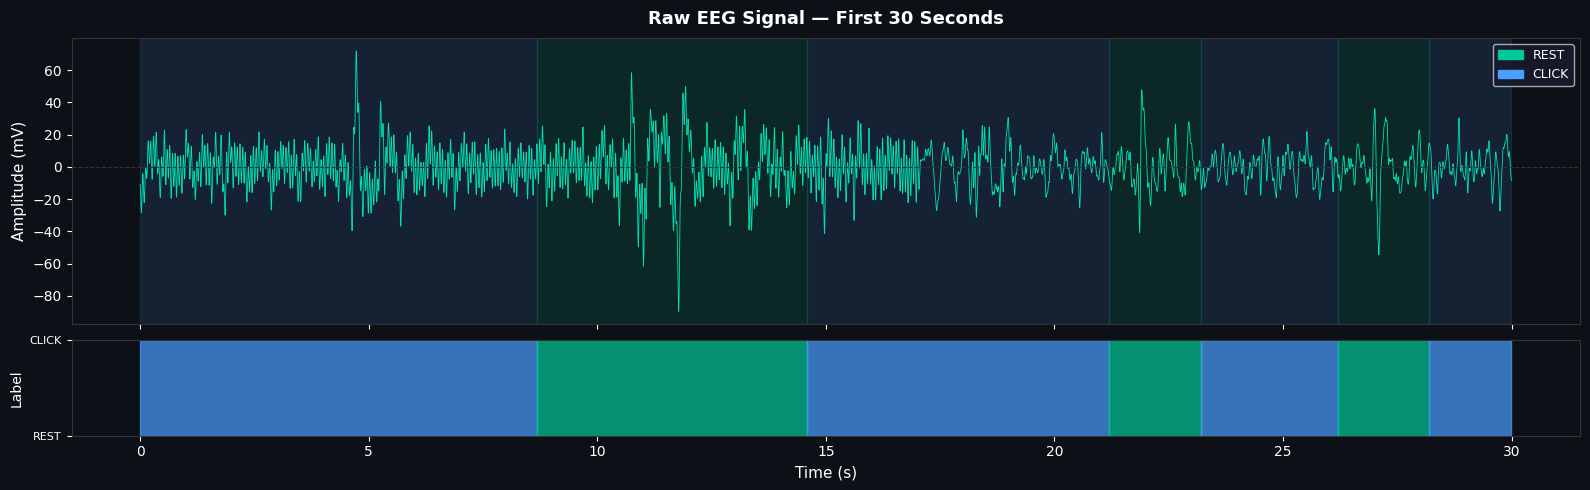

In [78]:
t = np.arange(len(signal)) / FS
window = int(30 * FS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 5), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0D1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='white'); ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values(): spine.set_color('#333')

ax1.plot(t[:window], signal[:window], color='#00F5C4', lw=0.6, alpha=0.9)
ax1.set_ylabel('Amplitude (mV)', color='white', fontsize=11)
ax1.set_title('Raw EEG Signal — First 30 Seconds', color='white', fontsize=13, fontweight='bold', pad=10)
ax1.axhline(0, color='#333', lw=0.8, ls='--')

# Label background shading
prev_lbl = labels_raw[0]; start_t = 0
for i in range(1, window):
    if labels_raw[i] != prev_lbl or i == window-1:
        c = COLORS[prev_lbl]
        ax1.axvspan(t[start_t], t[i], alpha=0.12, color=c)
        ax2.axvspan(t[start_t], t[i], alpha=0.7,  color=c)
        prev_lbl = labels_raw[i]; start_t = i

ax2.set_yticks([0, 5])
ax2.set_yticklabels(['REST', 'CLICK'], color='white', fontsize=8)
ax2.set_ylabel('Label', color='white', fontsize=10)
ax2.set_xlabel('Time (s)', color='white', fontsize=11)

from matplotlib.patches import Patch
patches = [Patch(color=COLORS[c], label=CLASS_NAMES[c]) for c in LABEL_ORDER]
ax1.legend(handles=patches, loc='upper right', facecolor='#1A1A2E', labelcolor='white', fontsize=9)

plt.tight_layout(h_pad=0.5)
plt.show()

## Trial Segmentation

In [79]:
# Detect exact label transitions → each continuous run = one BCI trial
transitions = np.where(np.diff(labels_raw) != 0)[0] + 1
boundaries  = np.concatenate([[0], transitions, [len(labels_raw)]])

segments = []
for i in range(len(boundaries) - 1):
    start, end = int(boundaries[i]), int(boundaries[i+1])
    lbl = labels_raw[start]
    seg = signal[start:end]
    if len(seg) >= 128:                     # skip very short fragments
        segments.append((seg, int(lbl)))

print(f"Total trials detected : {len(segments)}")
from collections import Counter
dist = Counter(s[1] for s in segments)
for cls, cnt in sorted(dist.items()):
    print(f"  Class {cls} ({CLASS_NAMES[cls]:5s}): {cnt} trials, "
          f"avg {np.mean([len(s[0]) for s in segments if s[1]==cls]):.0f} samples "
          f"({np.mean([len(s[0]) for s in segments if s[1]==cls])/FS:.1f}s)")


Total trials detected : 108
  Class 0 (REST ): 54 trials, avg 531 samples (2.1s)
  Class 5 (CLICK): 54 trials, avg 812 samples (3.2s)


## Feature Engineering 
#### 42 Features per Trial

In [80]:
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid

In [81]:
# ── Feature Engineering — 42 Features per Trial ───────────
FEATURE_NAMES = []

def band_power(f, pxx, lo, hi):
    idx = (f >= lo) & (f <= hi)
    return trapezoid(pxx[idx], f[idx]) if idx.sum() > 0 else 0.0

def spectral_entropy(pxx):
    p = pxx / (pxx.sum() + 1e-10)
    return float(-np.sum(p * np.log2(p + 1e-10)))

def hjorth_params(x):
    d1 = np.diff(x); d2 = np.diff(d1)
    act  = float(np.var(x))
    mob  = float(np.sqrt(np.var(d1) / (act  + 1e-10)))
    comp = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-10)) / (mob + 1e-10))
    return act, mob, comp

def extract_features(ep):
    nperseg = min(128, len(ep))
    d1 = np.diff(ep)
    half = len(ep) // 2

    # ── Time-domain (18 features) ───────────────────────────
    td = [
        float(np.mean(ep)),          # mean amplitude
        float(np.std(ep)),           # standard deviation
        float(np.var(ep)),           # variance
        float(skew(ep)),             # skewness
        float(kurtosis(ep)),         # excess kurtosis
        float(np.sqrt(np.mean(ep**2))),           # RMS
        float(np.max(ep) - np.min(ep)),           # peak-to-peak
        float(np.mean(np.abs(ep))),               # mean absolute value
        float(np.sum(np.diff(np.sign(ep)) != 0)), # zero-crossing rate
        float(np.percentile(ep, 10)),             # 10th pctile
        float(np.percentile(ep, 25)),             # 25th pctile
        float(np.percentile(ep, 75)),             # 75th pctile
        float(np.percentile(ep, 90)),             # 90th pctile
        float(np.sum(np.abs(d1))),                # line length (complexity proxy)
        float(np.mean(ep[:half])),                # first-half mean
        float(np.mean(ep[half:])),                # second-half mean
        float(np.std(ep[:half])),                 # first-half std
        float(np.std(ep[half:])),                 # second-half std
    ]

    # ── Hjorth parameters (3 features) ─────────────────────
    act, mob, comp = hjorth_params(ep)
    hj = [act, mob, comp]

    # ── Autocorrelation lags (5 features) ──────────────────
    ac = np.correlate(ep, ep, mode='full')
    ac = ac[len(ac)//2:]
    ac = ac / (ac[0] + 1e-10)
    autocorr = [float(ac[lag]) if lag < len(ac) else 0.0
                for lag in [1, 2, 5, 10, 20]]

    # ── Frequency-domain — Welch PSD (16 features) ─────────
    f, pxx = welch(ep, fs=FS, nperseg=nperseg)
    pxx = np.maximum(pxx, 1e-12)

    d_ = band_power(f, pxx, 2,  4)    # delta
    t_ = band_power(f, pxx, 4,  8)    # theta
    a_ = band_power(f, pxx, 8,  13)   # alpha
    b_ = band_power(f, pxx, 13, 30)   # beta
    g_ = band_power(f, pxx, 30, 45)   # gamma
    tot= band_power(f, pxx, 1,  50)   # total

    fd = [
        d_, t_, a_, b_, g_, tot,              # absolute band powers
        d_/(tot+1e-10),                        # relative delta
        t_/(tot+1e-10),                        # relative theta
        a_/(tot+1e-10),                        # relative alpha
        b_/(tot+1e-10),                        # relative beta
        a_ /(b_ +1e-10),                       # alpha/beta ratio (key MI feature)
        t_ /(a_ +1e-10),                       # theta/alpha ratio
        (a_+b_)/(d_+t_+1e-10),                # high/low ratio
        spectral_entropy(pxx),                 # spectral entropy
        float(f[np.argmax(pxx)]),              # peak frequency
        float(np.sum(pxx * f) / (np.sum(pxx)+1e-10)),  # spectral centroid
    ]

    return np.array(td + hj + autocorr + fd, dtype=np.float32)

# Build global feature name list
FEATURE_NAMES = (
    ['mean','std','var','skewness','kurtosis','rms','p2p','mav','zcr',
     'pct10','pct25','pct75','pct90','line_len','h1_mean','h2_mean','h1_std','h2_std']
  + ['hjorth_activity','hjorth_mobility','hjorth_complexity']
  + [f'autocorr_lag{l}' for l in [1,2,5,10,20]]
  + ['delta','theta','alpha','beta','gamma','total_power',
     'rel_delta','rel_theta','rel_alpha','rel_beta',
     'alpha_beta_ratio','theta_alpha_ratio','hilo_ratio',
     'spectral_entropy','peak_freq','spectral_centroid']
)

X = np.array([extract_features(s[0]) for s in segments])
y = np.array([s[1] for s in segments])

print(f"Feature matrix shape: {X.shape}  (trials × features)")
print(f"Feature names: {len(FEATURE_NAMES)}")
pd.DataFrame(X, columns=FEATURE_NAMES).describe().round(3)


Feature matrix shape: (108, 42)  (trials × features)
Feature names: 42


,mean,std,var,skewness,kurtosis,rms,p2p,mav,zcr,pct10,...,rel_delta,rel_theta,rel_alpha,rel_beta,alpha_beta_ratio,theta_alpha_ratio,hilo_ratio,spectral_entropy,peak_freq,spectral_centroid
count,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,...,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000,108.000
mean,-0.013,13.136,223.881,0.062,0.807,13.140,77.384,9.830,36.361,-15.678,...,0.344,0.409,0.149,0.064,3.203,3.779,0.307,2.670,3.074,5.323
std,0.329,7.198,329.118,0.459,1.588,7.198,47.487,4.610,25.392,7.417,...,0.102,0.060,0.064,0.062,1.764,3.870,0.173,0.299,1.406,1.131
min,-0.877,6.734,45.348,-0.844,-0.745,6.735,32.975,5.158,14.000,-49.914,...,0.128,0.236,0.011,0.004,0.085,0.867,0.015,1.727,2.000,2.665
25%,-0.207,8.769,76.905,-0.197,-0.161,8.783,47.371,7.002,25.000,-16.555,...,0.280,0.377,0.110,0.035,2.274,2.125,0.192,2.544,2.000,4.740
50%,-0.013,10.913,119.105,0.022,0.329,10.920,61.575,8.619,32.500,-13.229,...,0.332,0.409,0.149,0.054,2.746,2.968,0.277,2.726,2.000,5.341
75%,0.172,13.765,189.476,0.314,1.204,13.769,88.582,10.798,41.000,-11.467,...,0.385,0.447,0.187,0.072,3.726,3.802,0.394,2.873,4.000,6.029
max,0.946,44.435,1974.479,1.870,11.579,44.435,267.212,31.384,239.000,-8.095,...,0.674,0.529,0.325,0.463,11.524,35.750,1.032,3.184,8.000,9.008


## EEG Signal Band Power Distributed per Class

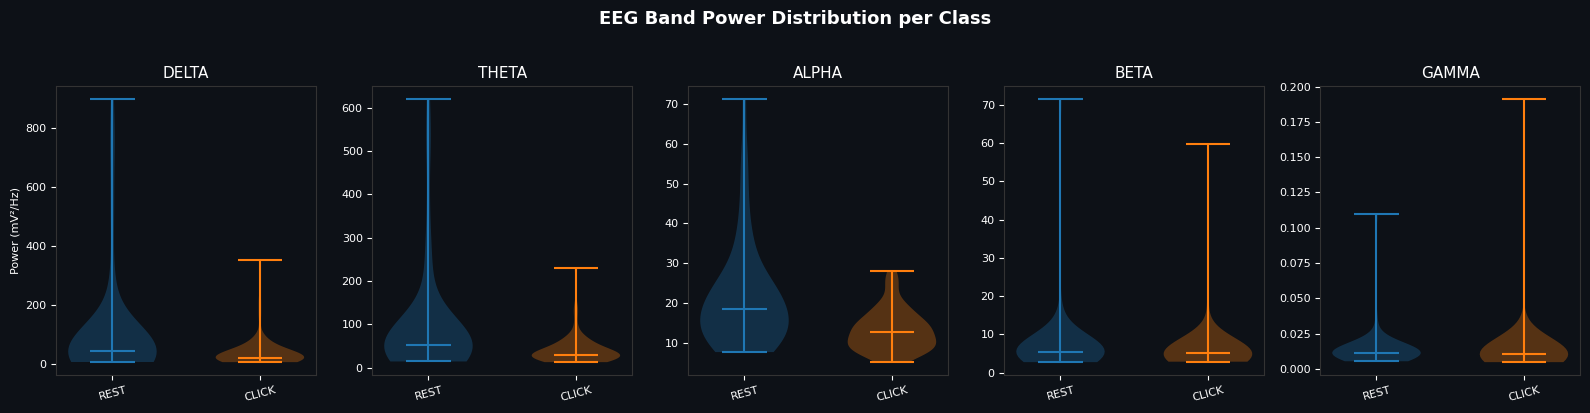

In [82]:
band_cols = ['delta','theta','alpha','beta','gamma']

feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df['Class'] = [CLASS_NAMES[yi] for yi in y]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('EEG Band Power Distribution per Class', color='white', fontsize=13, fontweight='bold', y=1.02)

for ax, band in zip(axes, band_cols):
    ax.set_facecolor('#0D1117')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_color('#333')

    for cls in ['REST', 'CLICK']:
        vals = feat_df[feat_df['Class']==cls][band].values
        c    = list(COLORS.values())[['REST','CLICK'].index(cls)]
        ax.violinplot([vals], positions=[['REST','CLICK'].index(cls)],
                      showmedians=True, widths=0.6)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['REST','CLICK'], rotation=15, fontsize=8, color='white')
    ax.set_title(band.upper(), color='white', fontsize=11)
    ax.set_ylabel('Power (mV²/Hz)' if band=='delta' else '', color='white', fontsize=8)

plt.tight_layout()
plt.show()


# Model Training
### Classification Model

In [83]:
# Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [84]:
X_scaled.shape

(108, 42)

In [85]:
# Using Ensemble Classifier Models

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

et = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)


### Classification Pipeline

In [86]:
# Using soft-voting ensemble where average predicted probabilities are used

ensemble = VotingClassifier(
    estimators=[('et', et), ('rf', rf)],
    voting='soft',
    n_jobs=-1,
)

In [87]:
ensemble

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=500, n_jobs=-1,
                                                   random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')

In [88]:
# 5-fold Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(ensemble, X_scaled, y, cv=cv, scoring='accuracy')

print("=" * 52)
print("  ExtraTrees + RandomForest Soft Voting Ensemble")
print("=" * 52)
print(f"  Fold accuracies : {[f'{s*100:.1f}%' for s in scores]}")
print(f"  Mean accuracy   : {scores.mean()*100:.1f}%")

  ExtraTrees + RandomForest Soft Voting Ensemble
  Fold accuracies : ['90.9%', '100.0%', '95.5%', '66.7%', '95.2%']
  Mean accuracy   : 89.7%


## Model Evaluation 

In [89]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [90]:
y_pred = cross_val_predict(ensemble, X_scaled, y, cv=cv, method='predict')

print("\nClassification Report:")
print(classification_report(y, y_pred,
      target_names=[CLASS_NAMES[c] for c in LABEL_ORDER],
      labels=LABEL_ORDER))


Classification Report:
              precision    recall  f1-score   support

        REST       0.88      0.93      0.90        54
       CLICK       0.92      0.87      0.90        54

    accuracy                           0.90       108
   macro avg       0.90      0.90      0.90       108
weighted avg       0.90      0.90      0.90       108



#### Plot Confusion Matrix

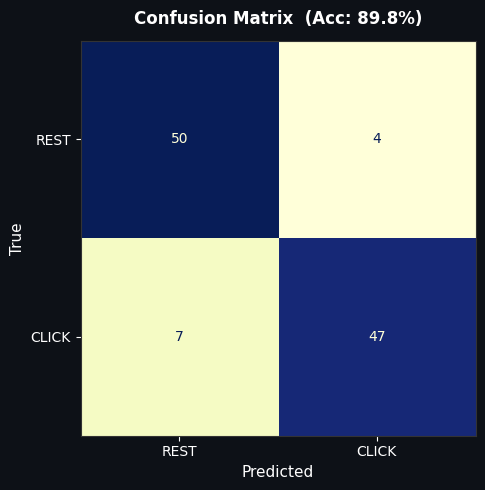

In [91]:
cm = confusion_matrix(y, y_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in LABEL_ORDER]
)
disp.plot(ax=ax, colorbar=False, cmap='YlGnBu')
ax.set_title(f'Confusion Matrix  (Acc: {accuracy_score(y,y_pred)*100:.1f}%)',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Predicted', color='white', fontsize=11)
ax.set_ylabel('True',      color='white', fontsize=11)
ax.xaxis.set_tick_params(labelcolor='white')
ax.yaxis.set_tick_params(labelcolor='white')

plt.tight_layout()
plt.show()


## Saving Final Model

In [92]:
import joblib

# Save the model to a file
joblib.dump(ensemble, 'BCI_MODEL.joblib')

print("Model saved successfully!")

Model saved successfully!


In [93]:
# Loading the model
import joblib

# Load the model from the file
loaded_model = joblib.load('BCI_MODEL.joblib')


In [94]:
loaded_model

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(class_weight='balanced',
                                                   n_estimators=500, n_jobs=-1,
                                                   random_state=42)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 n_jobs=-1, voting='soft')